
[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
🔹 CART Best Params: {'cart__max_depth': 5, 'cart__min_samples_leaf': 1, 'cart__min_samples_split': 2}
Train F1: 0.5103356837220515
Test  F1: 0.4958271968581247
⏱️ Tempo CART: 0 min 10.43 s
AUC CART: 0.8185158350301011
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      8727
           1       0.41      0.62      0.50      1625

    accuracy                           0.80     10352
   macro avg       0.67      0.73      0.69     10352
weighted avg       0.84      0.80      0.82     10352

🔸 RF Best Params: {'rf__max_depth': 7, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
Train F1: 0.5300954245167605
Test F1: 0.5217829262150592
⏱️ Tempo RF: 0 min 33.94 s
AUC RF: 0.8383470220623881
              precision    recall  f1-score   support

           0       0.93      0.85      0.89      8727
     

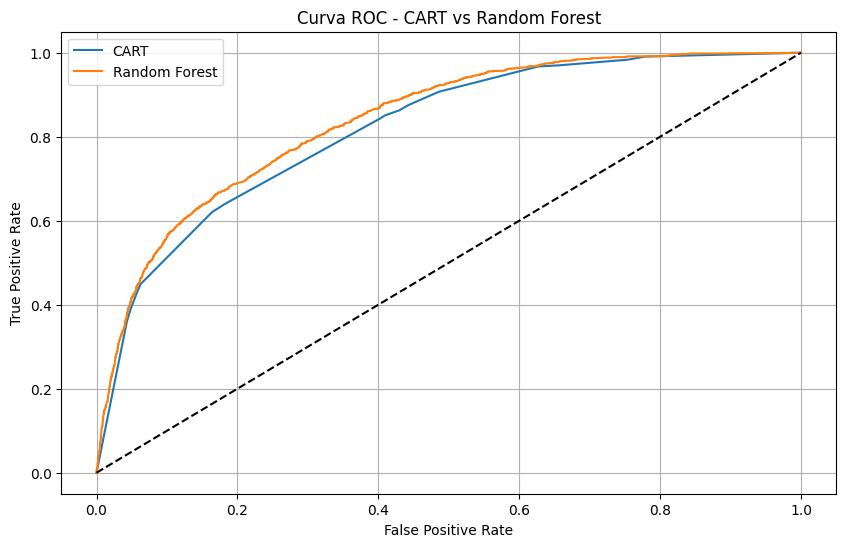

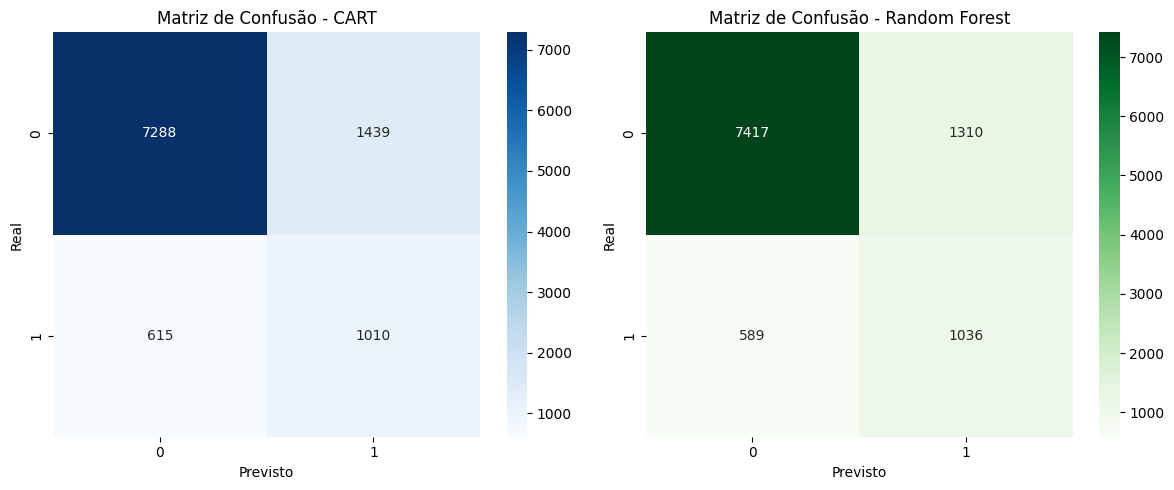

⏱️⏱️ Tempo total de execução do código: 0 min 57.17 s


In [1]:
# 📦 Instalar dependências
!pip install imbalanced-learn --quiet

# 🕒 Início do tempo total
import time
inicio_total = time.time()

# 📚 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 📥 Carregar o dataset
df = pd.read_csv("./INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)

# 📊 Pré-processamento
df = df[df['EVOLUCAO'].isin([1, 2])].copy()
df['EVOLUCAO'] = df['EVOLUCAO'].map({1: 0, 2: 1})

fatores_risco = ['PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
                 'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
                 'RENAL', 'OBESIDADE', 'OUT_MORBI']
variaveis = fatores_risco + ['FATOR_RISC', 'NU_IDADE_N', 'SUPORT_VEN', 'UTI', 'TOSSE']
df_model = df[variaveis + ['EVOLUCAO']].copy()

for col in variaveis:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
df_model.replace(9, np.nan, inplace=True)
df_model.dropna(inplace=True)

df_model['N_COMORB'] = df_model[fatores_risco].eq(1).sum(axis=1)
X = df_model.drop(columns=['EVOLUCAO'])
y = df_model['EVOLUCAO']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# 🔁 Pipelines
pipe_cart = ImbPipeline([('smote', SMOTE(random_state=42)),
                         ('cart', DecisionTreeClassifier(class_weight='balanced', random_state=42))])

pipe_rf = ImbPipeline([('smote', SMOTE(random_state=42)),
                       ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))])

# 🔍 Parâmetros
param_cart = {'cart__max_depth': [3, 5, 7],
              'cart__min_samples_leaf': [1, 2],
              'cart__min_samples_split': [2, 5]}

param_rf = {'rf__n_estimators': [100],
            'rf__max_depth': [5, 7],
            'rf__min_samples_leaf': [1, 2],
            'rf__min_samples_split': [2, 5]}

# 🚀 Treinar CART
start = time.time()
grid_cart = GridSearchCV(pipe_cart, param_grid=param_cart, scoring='f1', cv=5, n_jobs=-1)
grid_cart.fit(X_train, y_train)
end = time.time()
minutos, segundos = divmod(end - start, 60)
print("🔹 CART Best Params:", grid_cart.best_params_)
print("Train F1:", grid_cart.score(X_train, y_train))
print("Test  F1:", grid_cart.score(X_test, y_test))
print(f"⏱️ Tempo CART: {int(minutos)} min {round(segundos, 2)} s")
y_pred_cart = grid_cart.predict(X_test)
print("AUC CART:", roc_auc_score(y_test, grid_cart.predict_proba(X_test)[:, 1]))
print(classification_report(y_test, y_pred_cart))

# 🚀 Treinar Random Forest
start = time.time()
grid_rf = GridSearchCV(pipe_rf, param_grid=param_rf, scoring='f1', cv=5, n_jobs=-1)
grid_rf.fit(X_train, y_train)
end = time.time()
minutos, segundos = divmod(end - start, 60)
print("🔸 RF Best Params:", grid_rf.best_params_)
print("Train F1:", grid_rf.score(X_train, y_train))
print("Test F1:", grid_rf.score(X_test, y_test))
print(f"⏱️ Tempo RF: {int(minutos)} min {round(segundos, 2)} s")
y_pred_rf = grid_rf.predict(X_test)
print("AUC RF:", roc_auc_score(y_test, grid_rf.predict_proba(X_test)[:, 1]))
print(classification_report(y_test, y_pred_rf))

# 📉 Curva ROC
fpr_cart, tpr_cart, _ = roc_curve(y_test, grid_cart.predict_proba(X_test)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, grid_rf.predict_proba(X_test)[:, 1])

plt.figure(figsize=(10, 6))
plt.plot(fpr_cart, tpr_cart, label='CART')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - CART vs Random Forest')
plt.legend()
plt.grid()
plt.show()

# 📊 Matrizes de Confusão
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_cart), annot=True, fmt='d', cmap='Blues', ax=axs[0])
axs[0].set_title("Matriz de Confusão - CART")
axs[0].set_xlabel("Previsto")
axs[0].set_ylabel("Real")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=axs[1])
axs[1].set_title("Matriz de Confusão - Random Forest")
axs[1].set_xlabel("Previsto")
axs[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

# 🧮 Tempo total de execução
fim_total = time.time()
min_total, seg_total = divmod(fim_total - inicio_total, 60)
print(f"⏱️⏱️ Tempo total de execução do código: {int(min_total)} min {round(seg_total, 2)} s")


In [ ]:
## o que pode melhorar no codigo:

| Item                                         | Descrição                                                                                                 | Ação recomendada                                                                   |
| -------------------------------------------- | --------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------- |
| 💡 **Atributos hardcoded**                   | `file_path = "./INFLUD24-03-02-2025.csv"` está fixo, o que dificulta reutilização em diferentes ambientes | Criar parâmetro ou variável dinâmica para caminho do arquivo                       |
| 📌 **Uso de `.dropna()`**                    | Remove qualquer registro com `NaN`, o que pode excluir muitos dados — especialmente se houver muitos `9`s | Avaliar uso de imputação (ex: `SimpleImputer`) em vez de exclusão                  |
| 🔒 **Potencial vazamento de dados (leve)**   | Embora o pipeline esteja correto, as variáveis como `N_COMORB` são construídas antes da divisão           | Melhor criar `N_COMORB` **após** divisão ou validar que não se usa colunas futuras |
| 🧪 **Métrica única (F1)**                    | Apenas F1 é usada na otimização do `GridSearchCV`                                                         | Adicionar AUC-ROC ou recall como métrica complementar                              |
| 🧯 **Ausência de SHAP (como dito por você)** | O modelo é treinado corretamente, mas não há interpretação individual                                     | Pode ser deixado para extensão futura, conforme dito anteriormente                 |

